In [51]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector

sampler = StatevectorSampler()

### IIQC Trabalho 2, Miguel Curto Castela, uc2022212972 

### 2.1 Exercícios simples 1 <a id="ex1"></a>

1.	Escrever o produto Kronecker (produto tensorial) dos qubits:    
    a)	$|0\rangle\otimes|1\rangle$    
    b)	$|0\rangle\otimes|+\rangle$    
    c)	$|+\rangle\otimes|1\rangle$    
    d)	$|-\rangle\otimes|+\rangle$    

 tendo em conta que:

$$ |+\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = \tfrac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1 \end{bmatrix}$$
$$ |-\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle - |1\rangle) = \tfrac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ -1 \end{bmatrix} $$

Resposta ao exercício anexada na última página do  notebook em PDF e no PDF exercicios_manuscritos_2022212972.pdf incluído na entrega

2.	Escreva o estado:
    $|\psi\rangle = \frac{1}{\sqrt{2}}|00\rangle + \frac{i}{\sqrt{2}}|01\rangle$
    como dois qubits seperarados.


Resposta ao exercício anexada na última página do  notebook em PDF e no PDF exercicios_manuscritos_2022212972.pdf incluído na entrega

### 2.2 Exercícios simples 2 <a id="ex2"></a>

1. Calcule a unitária ($U$) de um circuito de um quibit  criado pela sequência de portas: $U = XZH$. Utilize o Qiskit para verificar os seus resultados.

Resposta ao exercício anexada na última página do  notebook em PDF e no PDF exercicios_manuscritos_2022212972.pdf incluído na entrega

In [52]:
#verificação feita com Qiskit
qc = QuantumCircuit(1)
qc.x(0)
qc.z(0)
qc.h(0)

unitary = Operator(qc).data
print("unitary matrix:")
print(unitary)

unitary matrix:
[[-0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]


2. Considere um circuito diferente com as mesmas portas, mas "empilhadas" para ter um circuito com 3 qubits, aplicando cada porta a um qubit diferente.
Calcule o seu produto kronecker (produto tensorial) para obter a unitária ($U$) do circuito de 3 quibits, em seguida, verifique a sua resposta utilizando o Qiskit.

Resposta ao exercício anexada na última página do  notebook em PDF e no PDF exercicios_manuscritos_2022212972.pdf incluído na entrega

In [53]:
#verificação feita com Qiskit
qc = QuantumCircuit(3)
qc.x(2)
qc.z(1)
qc.h(0)

unitary = Operator(qc).data
print("unitary matrix:")
print(unitary)

unitary matrix:
[[ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j -0.70710678+0.j -0.70710678+0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j -0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j -0.70710678+0.j -0.70710678+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j -0.70710678+0.j  0.

### Exercícios simples 3 <a id="ex3"></a>
1. Crie um circuito quântico que produza o estado de Bell: $\tfrac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$.
   Utilize o Qiskit para construir o circuito e statevector para verificar o seu resultado.

In [54]:
#Bell state: |psi⟩ = 1/sqrt(2) (|01⟩ + |10⟩)
#Circuit to create the Bell state
expectedBellState = Statevector([0, 1, 1, 0]) / np.sqrt(2)

qc = QuantumCircuit(2)
qc.x(1)
qc.h(0)
qc.cx(0, 1)

print(qc)

statevector = Statevector.from_instruction(qc)
print("circuit statevector", statevector)

if statevector.equiv(expectedBellState):
    print("O circuito produz o bell state esperado")
else:
    print("O circuito não produz o bell state esperado")

     ┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘
circuit statevector Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
O circuito produz o bell state esperado


2. O circuito que criou acima transforma o estado $|00\rangle$ em $\tfrac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$, calcule a matriz unitária deste circuito utilizando o Qiskit. Verifique se esta unitária realiza de facto a transformação correta.

In [55]:
#Matriz unitária do circuito
unitary = Operator(qc).data

print("unitary matrix:")
print(unitary)

initial_state = Statevector.from_label('00')
print("initial state:",initial_state)

final_state = initial_state.evolve(unitary)
print("final state:",final_state)

if statevector.equiv(expectedBellState):
    print("A matriz unitária produz o bell state esperado")
else:
    print("A matriz unitária não produz o bell state esperado")

unitary matrix:
[[ 0.        +0.j  0.        +0.j  0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j -0.70710678+0.j]]
initial state: Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
final state: Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
A matriz unitária produz o bell state esperado


### 2.4 Algoritmo Deutsch-Jozsa <a id="ex4"></a>

Apresente a sua implementação, simulação de alguns casos, e execução em hardware real de pelo menos dois casos aproventando o número de qubits disponiveis.

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
import os
from dotenv import load_dotenv

if "IBM_TOKEN" in os.environ:
    del os.environ["IBM_TOKEN"]
load_dotenv()
IBM_TOKEN = os.getenv("IBM_TOKEN")
#print(f"IBM_TOKEN: {IBM_TOKEN}")
service = QiskitRuntimeService(channel="ibm_quantum", token=IBM_TOKEN)
backend = service.least_busy(operational=True, simulator=False)
sim = AerSimulator()
print(backend)




<IBMBackend('ibm_kyiv')>


In [57]:
def constantOracle(len):
    oracle = QuantumCircuit(len+1)
    
    oracle.barrier()
    
    output = np.random.randint(2)
    if(output == 1):
        oracle.x(len)

    oracle.barrier()

    return oracle

def balancedOracle(len):
    oracle = QuantumCircuit(len+1)
    
    oracle.barrier()

    #Random implementation
    b = np.random.randint(1, 2**len)
    b_str = format(b, '0'+str(len)+'b')
    
    for qb in range(len):
        if(b_str[qb] == '1'):
            oracle.x(qb)

        
    for qb in range(len):
        oracle.cx(qb, len)
        
    for qb in range(len):
        if(b_str[qb] == '1'):
            oracle.x(qb)    

    oracle.barrier()

    #Static implementation 
    '''
    oracle = QuantumCircuit(len+1)

    oracle.barrier()

    for qb in range(len):
        if(qb % 2 == 0):
            oracle.x(qb)

    oracle.barrier()

    for qb in range(len):
        oracle.cx(qb, len)

    oracle.barrier()

    for qb in range(len):
        if(qb % 2 == 0):
            oracle.x(qb)    

    oracle.barrier()
    '''

    return oracle

In [58]:
def createOracle(len):
    constant = constantOracle(len)
    balanced = balancedOracle(len)
    
    return constant, balanced

In [59]:
def createCircuit_dj(len, oracle):
    dj = QuantumCircuit(len+1, len)
    
    #input qubits
    for qb in range(len):
        dj.h(qb)
        
    #output qubit
    dj.x(len)
    dj.h(len)
    
    #apply the oracle
    dj = dj.compose(oracle)
    
    #apply Hadamard gates to the first n qubits
    for qb in range(len):
        dj.h(qb)
        
    #measure the first n qubits
    for qb in range(len):
        dj.measure(qb, qb)
    
    return dj    

def simulateCircuit_dj(dj):
    job = sim.run(dj)
    results = job.result()
    graph = results.get_counts()
    plot_histogram(graph)

def runCircuit_dj(dj):
    transpiledCircuit = transpile(dj, backend, optimization_level=3)
    transpiledCircuit.draw('mpl', idle_wires=False)
    
    job = backend.run([transpiledCircuit], shots=1024)
    job.job_id()
    
    results = job.result()
    graph = results.get_counts()
    
    plot_histogram(graph)
    
def jobResults(job_id):
    job = service.job(job_id)
    results = job.result()
    graph = results.get_counts()
    plot_histogram(graph)
    #plt.show()

#número de qubits (no Deutsh-Josza e no grover)
len = 4

#create the oracles
constantOracle, balancedOracle = createOracle(len)

Deutch-Jozsa circuit with balanced oracle 


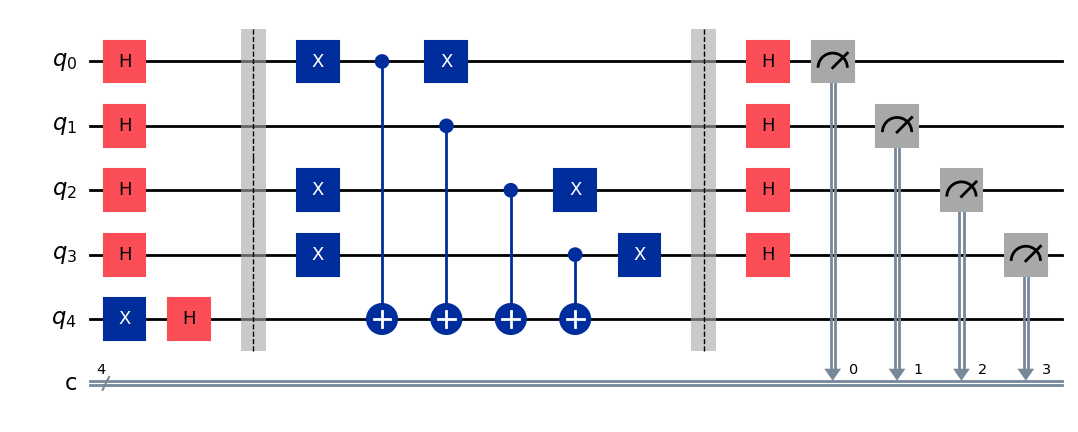

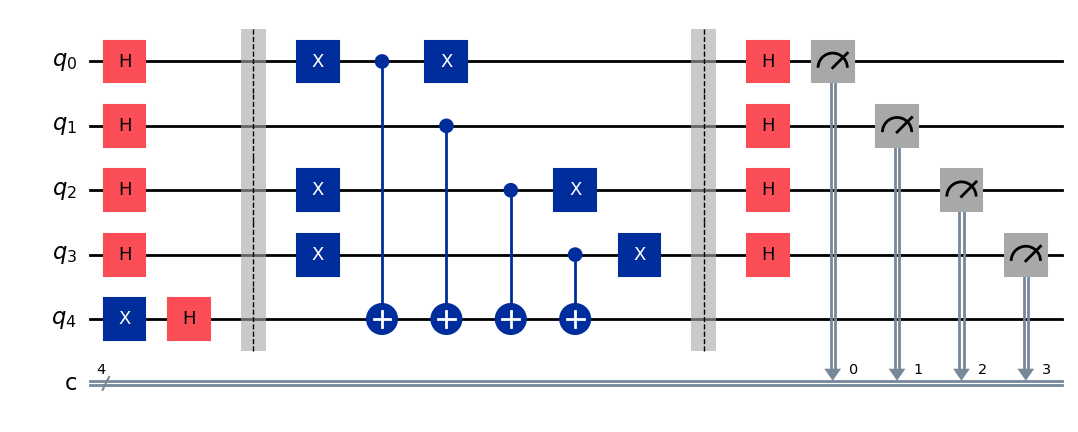

In [60]:
#Deutsch-Jozsa circuit with balanced oracle
balancedDj = createCircuit_dj(len, balancedOracle)

#run it on real hardware
#runCircuit_dj(balancedDj)

print("Deutch-Jozsa circuit with balanced oracle ")
balancedDj.draw('mpl', idle_wires=False)


In [61]:
#print("simulation of the Deutch-Jozsa circuit with balanced oracle ")
#print(balancedDj)

results of the simulation


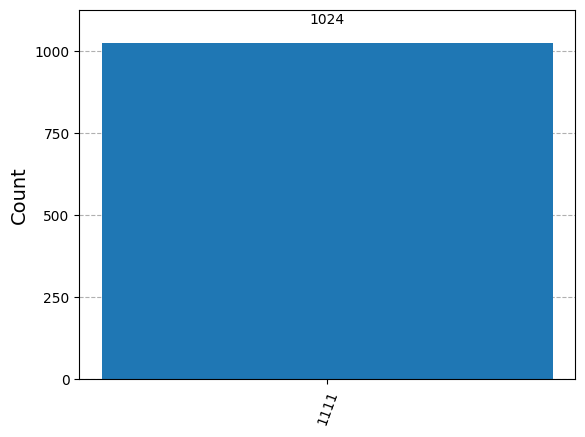

In [62]:
print("results of the simulation")
simulateCircuit_dj(balancedDj)

balanced iracle job results:


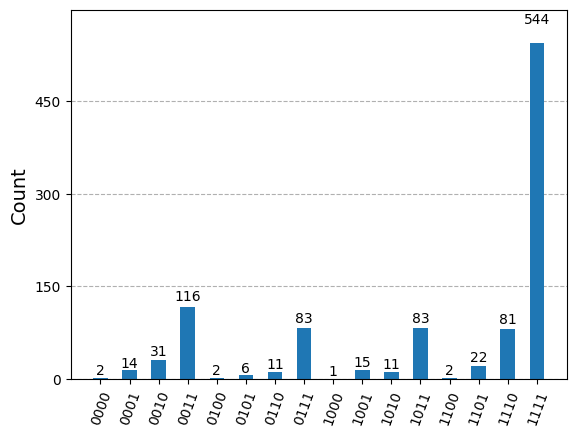

In [63]:
print("balanced iracle job results:")
jobResults("cxde3j6vw7kg008atm10")

Deutch-Jozsa circuit with constant oracle 


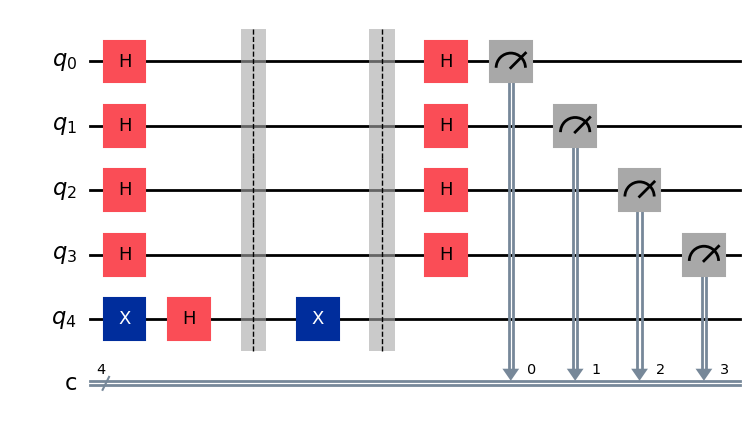

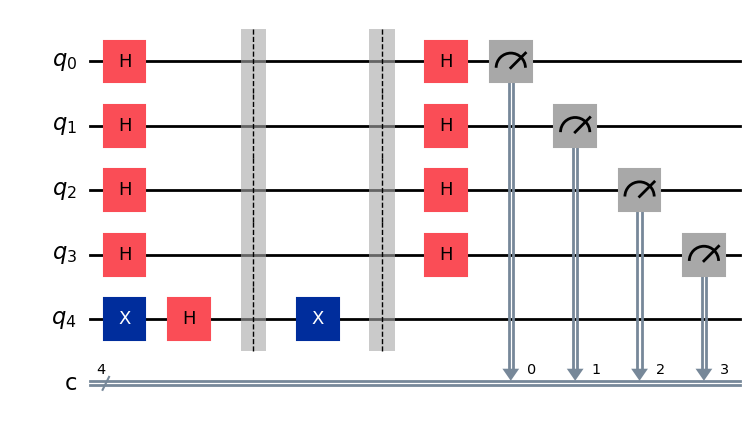

In [64]:
#Deutsch-Jozsa circuit with the constant oracle
constantDj = createCircuit_dj(len, constantOracle)
# run it on real hardware
#runCircuit_dj(constantDj)
print("Deutch-Jozsa circuit with constant oracle ")
constantDj.draw('mpl', idle_wires=False)

In [65]:
#print("simulation of the Deutch-Jozsa circuit with constant oracle ")
#print(constantDj)

results of the simulation


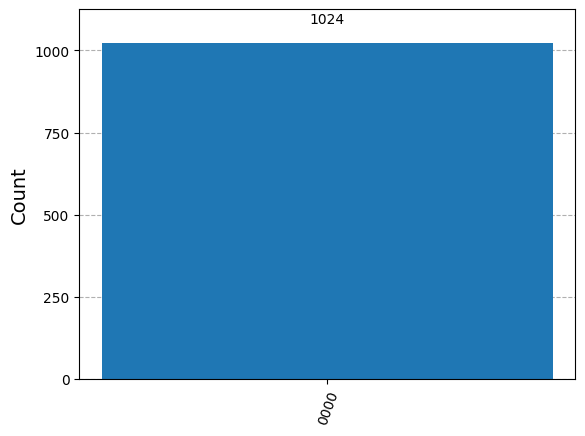

In [66]:
print("results of the simulation")
simulateCircuit_dj(constantDj)

constant oracle job results:


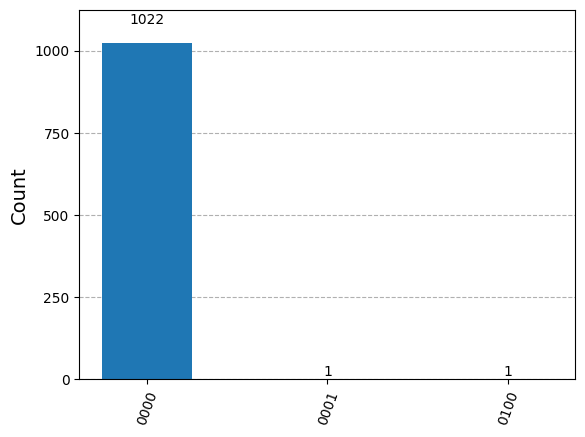

In [67]:
print("constant oracle job results:")
jobResults("cxdejdh3ej4g0089x87g")


### 2.5 Grover's Algorithm <a id="ex5"></a>

Apresente a sua implementação, simulação de alguns casos, e execução em hardware real de pelo menos dois casos aproventando o número de qubits disponiveis.

In [68]:
def createPhaseOracle_1():
    #states: |0101>, |0110>, |1100>, |1111>
    oracle1 = QuantumCircuit(len)
    oracle1.barrier()
    oracle1.cz(0, 2)
    oracle1.cz(1, 2)
    oracle1.cz(2, 3)
    oracle1.barrier()
    return oracle1

def createPhaseOracle_2():
    #states: |0110>, |0111>, |1100>, |1101>
    oracle2 = QuantumCircuit(len)
    oracle2.barrier()
    oracle2.cz(1, 2)
    oracle2.cz(2, 3)
    oracle2.barrier()    
    return oracle2

In [69]:
def createDiffuser():
    diffuser = QuantumCircuit(len)
    diffuser.barrier()
    
    for qubit in range(len):
        diffuser.h(qubit)
        
    for qubit in range(len):
        diffuser.x(qubit)
        
    diffuser.h(len-1)
    diffuser.mcx(list(range(len-1)), len-1)
    diffuser.h(len-1)
    
    for qubit in range(len):
        diffuser.x(qubit)
        
    for qubit in range(len):
        diffuser.h(qubit)
    diffuser.barrier()
        
    return diffuser

In [70]:
def createCircuit1_grover():
    grover1 = QuantumCircuit(len)
    
    for qubit in range(len):
        grover1.h(qubit)
    
    #target states
    grover1 = grover1.compose(createPhaseOracle_1(), list(range(len)))

    grover1 = grover1.compose(createDiffuser(), list(range(len)))
    grover1.measure_all()
    
    return grover1

def createCircuit2_grover():
    grover2 = QuantumCircuit(len)
    
    for qubit in range(len):
        grover2.h(qubit)
    
    #target states
    grover2 = grover2.compose(createPhaseOracle_2(), list(range(len)))
        
    grover2 = grover2.compose(createDiffuser(), list(range(len)))
    grover2.measure_all()
    
    return grover2

In [71]:
def runCircuit_grover(grover):
    transpiledGrover = transpile(grover, backend)
    transpiledGrover.draw('mpl', idle_wires=False)
    
    job = backend.run([transpiledGrover], shots=1024)
    job.job_id()
    
    results = job.result()
    graph = results.get_counts()
    plot_histogram(graph)

In [72]:
def simulateCircuit_grover(grover):
    job = sim.run(grover)
    result = job.result()
    graph = result.get_counts()
    plot_histogram(graph)

grover_1 circuit for the first oracle:


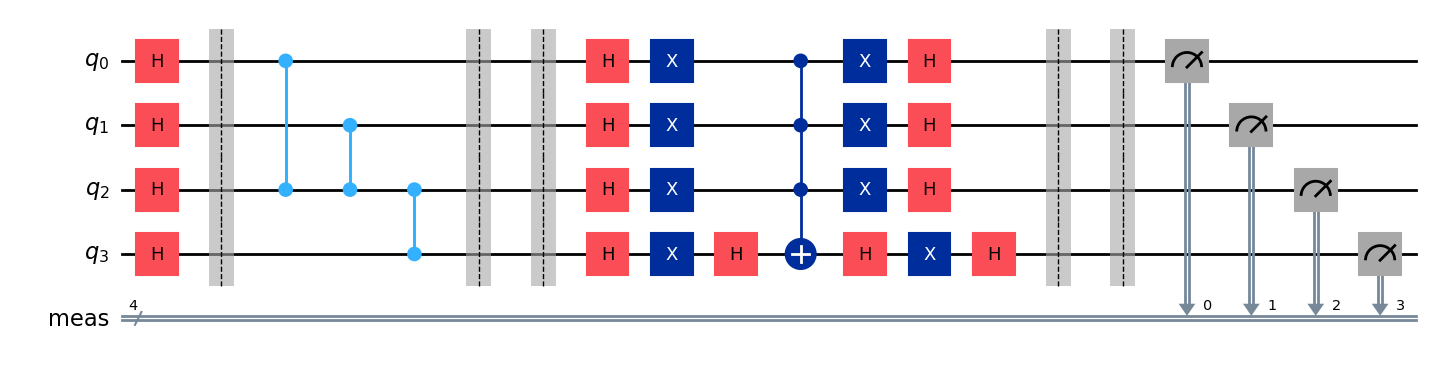

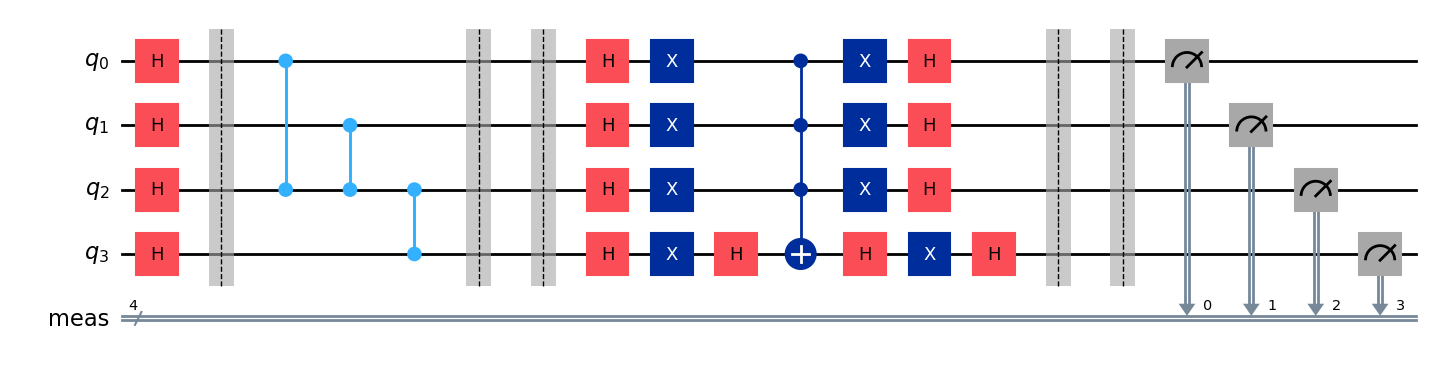

In [73]:
#create grover circuit (with oracle 1)
grover_1 = createCircuit1_grover()

#run it on real hardware
#runCircuit_grover(grover_1)

print("grover_1 circuit for the first oracle:")
grover_1.draw('mpl', idle_wires=False)

In [74]:
#print("grover_1 circuit simulation:")
#print (grover_1)

grover_1 simulation results:


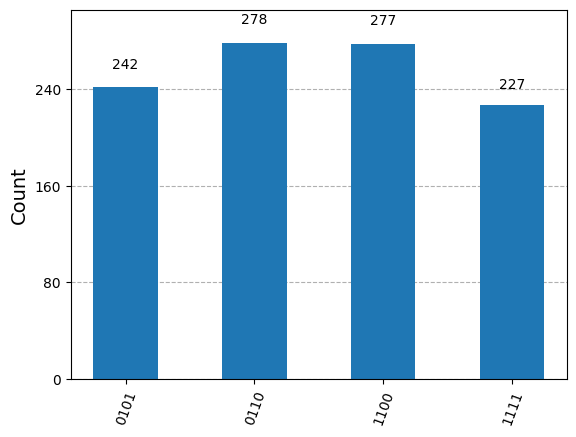

In [75]:
print("grover_1 simulation results:")
simulateCircuit_grover(grover_1)

grover_1 job results:


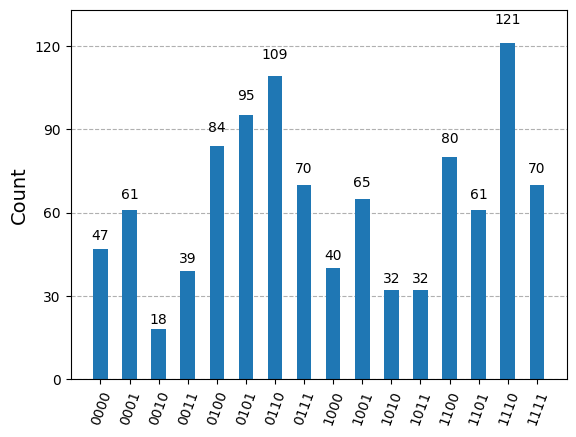

In [76]:
print("grover_1 job results:")
jobResults("cxdejvkgcckg008bgve0")

grover_2 circuit for the second oracle:


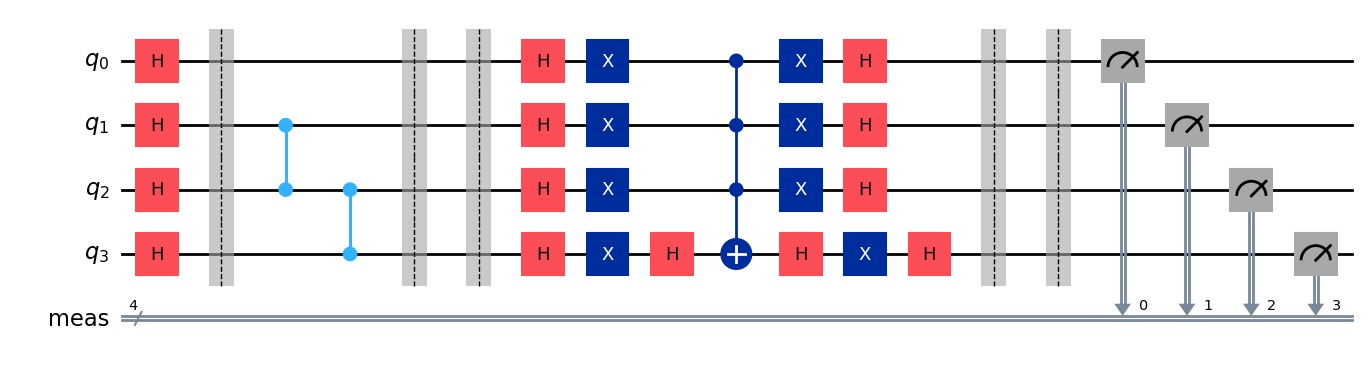

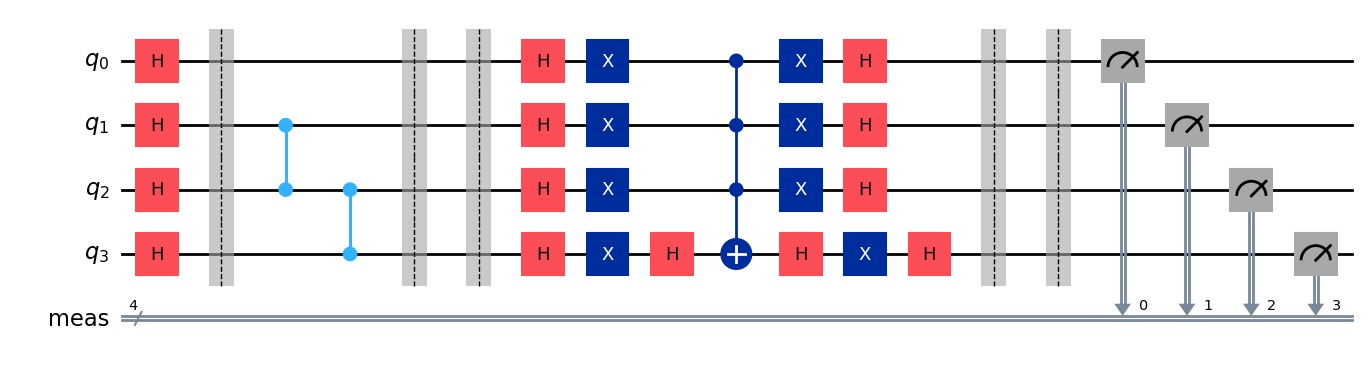

In [77]:
# create grover circuit (with oracle 2)
grover_2 = createCircuit2_grover()

#run it on real hardware
#runCircuit_grover(grover_2)

print("grover_2 circuit for the second oracle:")
grover_2.draw('mpl', idle_wires=False)

In [78]:
#print("grover_2 circuit simulation:")
#print (grover_2)

grover_2 simulation results:


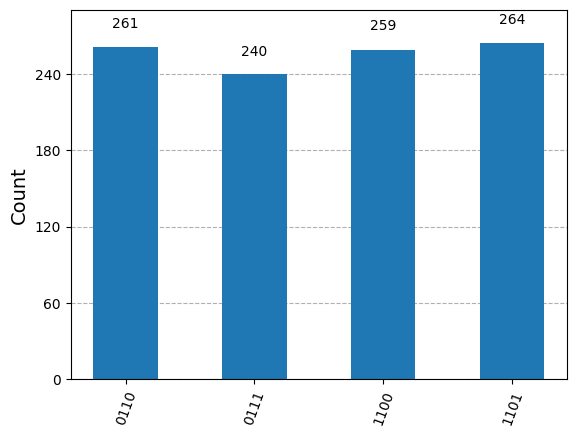

In [79]:
print("grover_2 simulation results:")
simulateCircuit_grover(grover_2)

grover_2 job results:


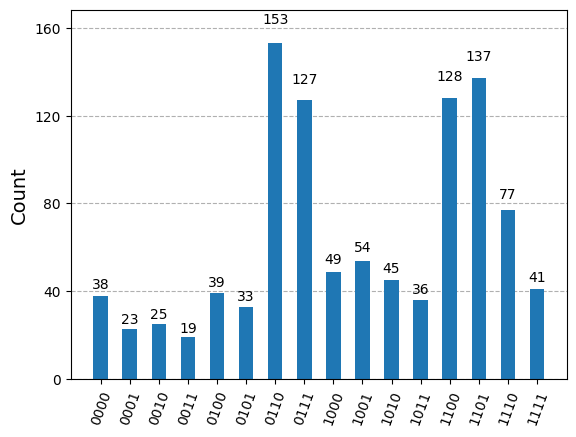

In [80]:
print("grover_2 job results:")
jobResults("cxdek2cfdnwg008s0s00")